### Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

### Load the data

In [2]:
df = pd.read_csv("second_hand_cars.csv")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 2,500 | Columns: 16


,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Make Year,2500.0,2019.5216,2.894146,2015.0,2017.0,2020.0,2022.00,2024.0
Mileage,2500.0,104777.7920,55544.487467,10010.0,56313.0,104209.5,152149.25,199755.0
Price,2500.0,608120.8976,231056.126713,200176.0,407791.0,612012.5,804567.00,999826.0


###  Data Cleaning


In [5]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(1),
})
missing[missing["missing"] > 0]

,missing,percent
Variant,262,10.5
Accessories,482,19.3


In [6]:
df_clean = df.copy()

# Tidy column names -> snake_case
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

# Missing values
df_clean["variant"] = df_clean["variant"].fillna("Unknown")
df_clean["accessories"] = df_clean["accessories"].fillna("None")

print("Missing values left:", int(df_clean.isna().sum().sum()))

Missing values left: 0


**Removing duplicates.** 

In [7]:
print("Fully duplicated rows      :", df_clean.duplicated().sum())
print("Duplicated registration no.:", df_clean["registration_number"].duplicated().sum())

df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop(columns=["registration_number"])
print("Shape after cleaning       :", df_clean.shape)

Fully duplicated rows      : 0
Duplicated registration no.: 0
Shape after cleaning       : (2500, 15)


**Data type conversion.**

In [8]:
cat_cols = ["company_name", "car_name", "variant", "fuel_type", "tyre_condition",
            "owner_type", "transmission_type", "body_color", "insurance",
            "registration_certificate"]
df_clean[cat_cols] = df_clean[cat_cols].astype("category")
df_clean.dtypes

company_name                category
car_name                    category
variant                     category
fuel_type                   category
tyre_condition              category
make_year                      int64
owner_type                  category
mileage                        int64
price                          int64
transmission_type           category
body_color                  category
service_record                   str
insurance                   category
registration_certificate    category
accessories                      str
dtype: object

### Data Exploratory Checks


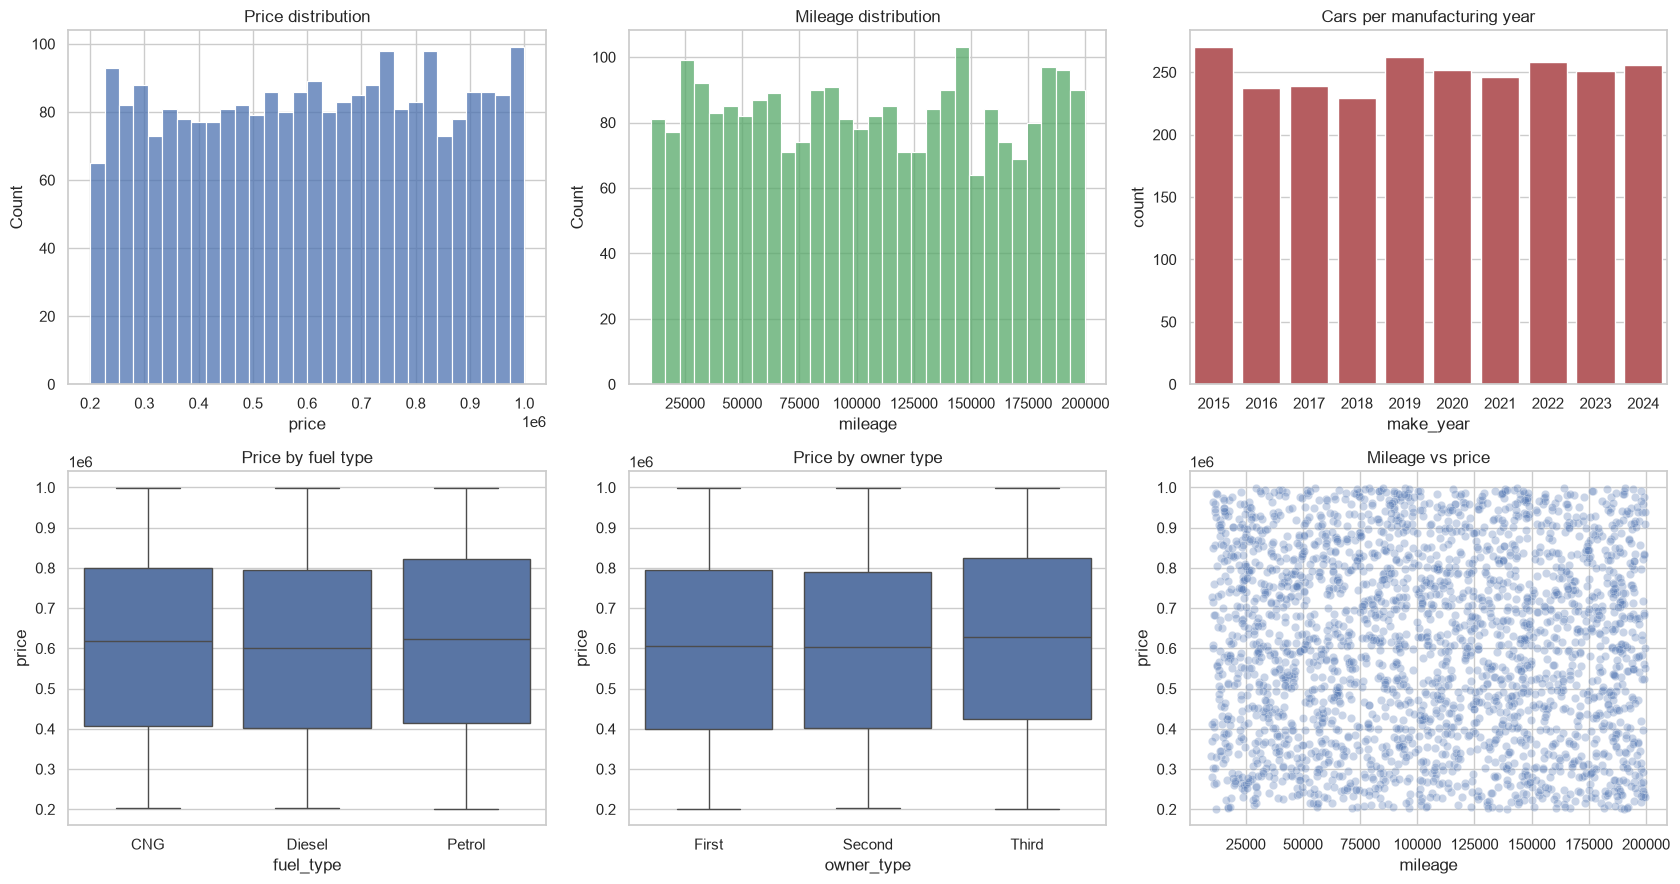

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

sns.histplot(df_clean["price"], bins=30, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Price distribution")

sns.histplot(df_clean["mileage"], bins=30, ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Mileage distribution")

sns.countplot(x="make_year", data=df_clean, ax=axes[0, 2], color="#C44E52")
axes[0, 2].set_title("Cars per manufacturing year")

sns.boxplot(x="fuel_type", y="price", data=df_clean, ax=axes[1, 0])
axes[1, 0].set_title("Price by fuel type")

sns.boxplot(x="owner_type", y="price", data=df_clean, ax=axes[1, 1],
            order=["First", "Second", "Third"])
axes[1, 1].set_title("Price by owner type")

sns.scatterplot(x="mileage", y="price", data=df_clean, alpha=0.3, ax=axes[1, 2])
axes[1, 2].set_title("Mileage vs price")

plt.tight_layout()
plt.show()

In [10]:
# Outlier check (IQR rule) and make/model sanity check
for col in ["price", "mileage"]:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_clean[col] < q1 - 1.5 * iqr) | (df_clean[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col:<8} IQR outliers: {n_out}")

combos = df_clean.groupby(["company_name", "car_name"], observed=True).size()
print(f"\nDistinct make/model combinations: {len(combos)} "
      f"(10 makes x 10 models = 100 possible)")

print("\nCorrelation of numeric columns with price:")
print(df_clean[["make_year", "mileage", "price"]].corr()["price"].round(3))

price    IQR outliers: 0
mileage  IQR outliers: 0

Distinct make/model combinations: 100 (10 makes x 10 models = 100 possible)

Correlation of numeric columns with price:
make_year   -0.000
mileage     -0.028
price        1.000
Name: price, dtype: float64


**Observations**
- price  and mileage  are spread roughly evenly across their ranges, with no outliers to treat.
- Price has zero correlation with year and mileage, and its average barely changes across fuel type or owner type. 

### Feature Engineering
#### Creating New Features
- car_age = reference year make_year.
- price_per_mile = price / mileage. 
- mileage_per_year = mileage/ car_age
- **Service record features** parsed from free text: service_type (None / Full / Major) and major_service_km.
- **Accessory features**: one flag per accessory plus acc_count.
- **Binary flags** for insurance and registration_certificate.
- **Ordinal encodings** for owner_type (1–3) and tyre_condition (0 = needs replacement, 1 = used, 2 = new), which have a natural order.

In [11]:
REFERENCE_YEAR = 2025
df_fe = df_clean.copy()

# --- numeric features
df_fe["car_age"] = REFERENCE_YEAR - df_fe["make_year"]
df_fe["price_per_mile"] = df_fe["price"] / df_fe["mileage"]       # EDA only - leaks the target!
df_fe["mileage_per_year"] = df_fe["mileage"] / df_fe["car_age"]

# --- service record (free text)
sr = df_fe["service_record"]
df_fe["service_type"] = np.select(
    [sr.eq("No Service Record"), sr.eq("Full Service History")],
    ["None", "Full"], default="Major")
df_fe["major_service_km"] = sr.str.extract(r"(\d+)", expand=False).astype(float).fillna(0)

# --- accessories (multi-label -> one flag per accessory)
acc_flags = (df_fe["accessories"].str.get_dummies(sep=", ")
             .drop(columns="None", errors="ignore")
             .add_prefix("acc_")
             .rename(columns=lambda c: c.replace(" ", "_").lower()))
df_fe = pd.concat([df_fe, acc_flags], axis=1)
df_fe["acc_count"] = acc_flags.sum(axis=1)

# --- binary flags
df_fe["has_insurance"] = (df_fe["insurance"] != "No Current Insurance").astype(int)
df_fe["has_reg_certificate"] = (df_fe["registration_certificate"] == "Available").astype(int)

# --- ordinal encodings
df_fe["owner_ord"] = df_fe["owner_type"].map({"First": 1, "Second": 2, "Third": 3}).astype(int)
df_fe["tyre_ord"] = df_fe["tyre_condition"].map(
    {"Needs Replacement": 0, "Used": 1, "New": 2}).astype(int)

df_fe[["make_year", "car_age", "mileage", "mileage_per_year", "price", "price_per_mile",
       "service_type", "major_service_km", "acc_count", "has_insurance",
       "has_reg_certificate", "owner_ord", "tyre_ord"]].head()

,make_year,car_age,mileage,mileage_per_year,price,price_per_mile,service_type,major_service_km,acc_count,has_insurance,has_reg_certificate,owner_ord,tyre_ord
0,2018,7,52798,7542.571429,759107,14.377571,Major,50418.0,3,0,0,2,0
1,2020,5,43412,8682.400000,505071,11.634364,Major,131313.0,0,0,1,3,2
2,2022,3,95219,31739.666667,635322,6.672219,None,0.0,0,0,1,2,2
3,2024,1,70370,70370.000000,483152,6.865880,Major,98115.0,2,1,1,3,1
4,2018,7,85852,12264.571429,712961,8.304536,Major,135665.0,2,0,0,2,1


###  Encoding Categorical Features
Brings about perfect multicollinarity

In [12]:
ohe_cols = ["company_name", "car_name", "variant", "fuel_type",
            "transmission_type", "body_color", "service_type"]

ohe = pd.get_dummies(df_fe[ohe_cols].astype(str), drop_first=True, dtype=int)

numeric_cols = ["car_age", "make_year", "mileage", "mileage_per_year",
                "major_service_km", "acc_count", "owner_ord", "tyre_ord"]
binary_cols = ["has_insurance", "has_reg_certificate"] + list(acc_flags.columns)

X = pd.concat([df_fe[numeric_cols + binary_cols], ohe], axis=1)
y = df_fe["price"]

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"  numeric/ordinal : {len(numeric_cols)}")
print(f"  binary flags    : {len(binary_cols)}")
print(f"  one-hot columns : {ohe.shape[1]}")

Feature matrix: 2,500 rows x 55 columns
  numeric/ordinal : 8
  binary flags    : 7
  one-hot columns : 40


###  Feature Scaling
**Train/test split first.** To avoid leakage, we split the data before fitting the scaler, so the mean and standard deviation are learned from the training rows only.

**Standardization.** The numeric and ordinal columns are standardized to zero mean and unit variance using the StandardScaler. Binary and one-hot columns are already on a 0/1 scale and are left as they are.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])   # fit on train only
X_test_s[numeric_cols] = scaler.transform(X_test[numeric_cols])         # apply to test

print("Train:", X_train_s.shape, "| Test:", X_test_s.shape)
X_train_s[numeric_cols].describe().loc[["mean", "std"]].round(3)

Train: (2000, 55) | Test: (500, 55)


,car_age,make_year,mileage,mileage_per_year,major_service_km,acc_count,owner_ord,tyre_ord
mean,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



###  Correlation Analysis
We compute the correlation matrix of the training features and remove one feature from every pair whose absolute correlation exceeds **0.90**.

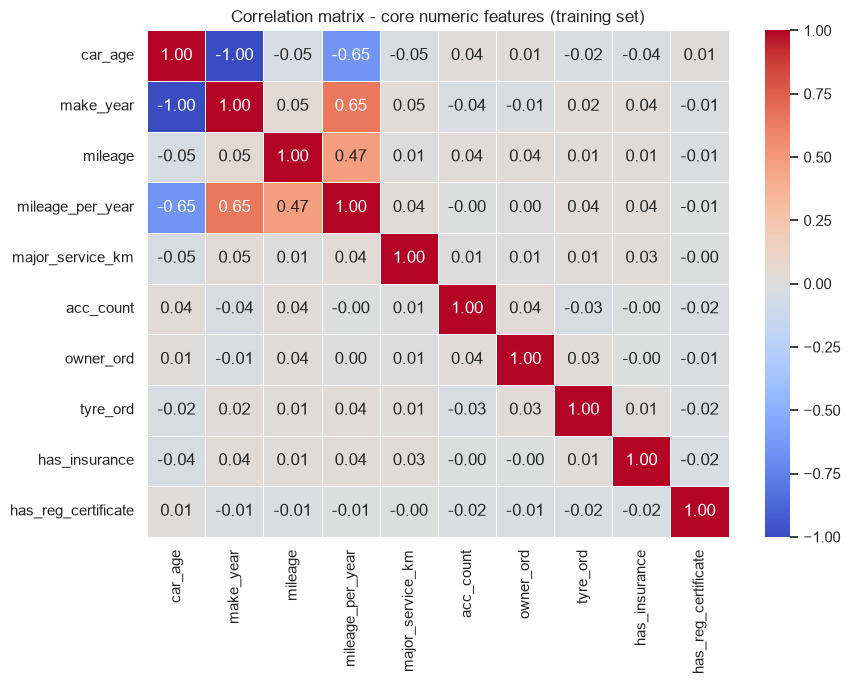

In [14]:
core = ["car_age", "make_year", "mileage", "mileage_per_year", "major_service_km",
        "acc_count", "owner_ord", "tyre_ord", "has_insurance", "has_reg_certificate"]

plt.figure(figsize=(9, 7))
sns.heatmap(X_train_s[core].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation matrix - core numeric features (training set)")
plt.tight_layout()
plt.show()

In [15]:
THRESHOLD = 0.90
corr = X_train_s.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))

# list every offending pair
pairs = (upper.stack()
         .loc[lambda s: s > THRESHOLD]
         .sort_values(ascending=False)
         .rename("abs_corr")
         .reset_index()
         .rename(columns={"level_0": "feature_1", "level_1": "feature_2"}))
print(f"Pairs with |r| > {THRESHOLD}:")
display(pairs)

to_drop = [c for c in upper.columns if (upper[c] > THRESHOLD).any()]
print("\nColumns removed:", to_drop)

X_train_r = X_train_s.drop(columns=to_drop)
X_test_r = X_test_s.drop(columns=to_drop)
print(f"Features: {X_train_s.shape[1]} -> {X_train_r.shape[1]}")

Pairs with |r| > 0.9:


,feature_1,feature_2,abs_corr
0,car_age,make_year,1.000000
1,major_service_km,service_type_Major,0.944046



Columns removed: ['make_year', 'service_type_Major']
Features: 55 -> 53


In [16]:
# How related is each remaining feature to the target? (training set only)
target_corr = X_train_r.corrwith(y_train).sort_values(key=np.abs, ascending=False)
print("Top 10 |correlation| with price:")
print(target_corr.head(10).round(3))
print(f"\nLargest absolute correlation with price: {target_corr.abs().max():.3f}")

Top 10 |correlation| with price:
car_name_Camry              0.058
owner_ord                   0.049
company_name_Toyota        -0.049
variant_SL                 -0.042
body_color_Grey             0.038
company_name_Ford           0.037
body_color_White            0.034
acc_alloy_wheels            0.032
transmission_type_Manual   -0.027
body_color_Silver          -0.025
dtype: float64

Largest absolute correlation with price: 0.058


###  Principal Component Analysis (PCA)
Standardizing  all remaining columns including the 0/1 columns so every feature contributes on the same scale. 

Original features        : 53
Components for 80% var.  : 35
Components for 90% var.  : 40
Components for 95% var.  : 44


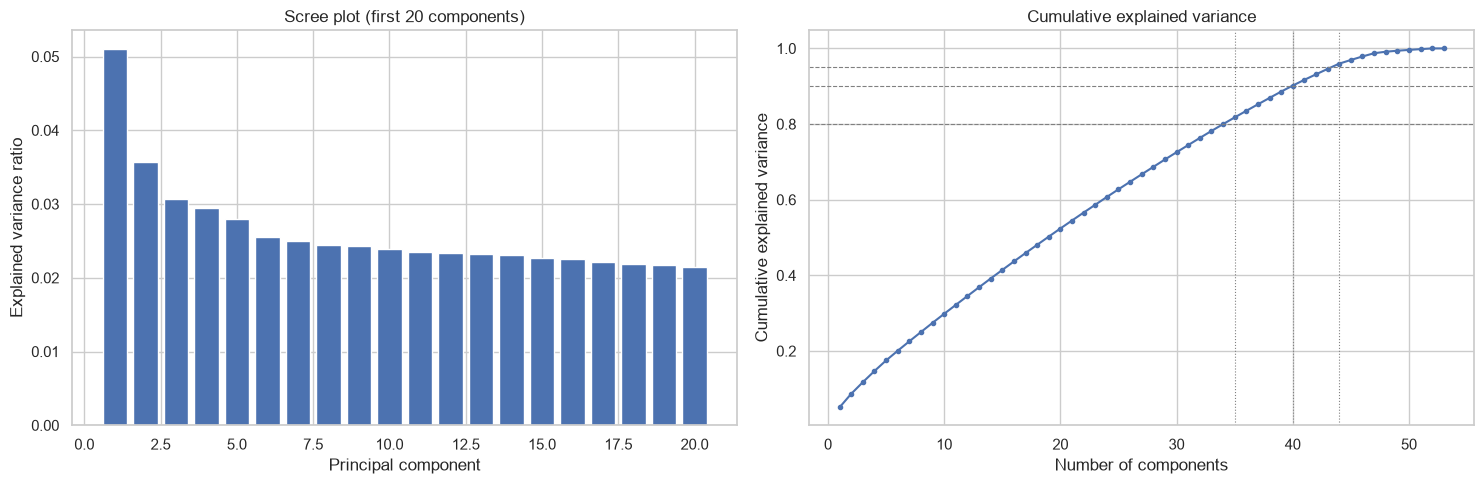

In [17]:
scaler_pca = StandardScaler().fit(X_train_r)
Xtr_std = scaler_pca.transform(X_train_r)
Xte_std = scaler_pca.transform(X_test_r)

pca_full = PCA(random_state=RANDOM_STATE).fit(Xtr_std)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n80 = int(np.argmax(cum_var >= 0.80) + 1)
n90 = int(np.argmax(cum_var >= 0.90) + 1)
n95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Original features        : {Xtr_std.shape[1]}")
print(f"Components for 80% var.  : {n80}")
print(f"Components for 90% var.  : {n90}")
print(f"Components for 95% var.  : {n95}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color="#4C72B0")
axes[0].set_title("Scree plot (first 20 components)")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker="o", ms=3)
for thr, n in [(0.80, n80), (0.90, n90), (0.95, n95)]:
    axes[1].axhline(thr, ls="--", c="grey", lw=0.8)
    axes[1].axvline(n, ls=":", c="grey", lw=0.8)
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")

plt.tight_layout()
plt.show()

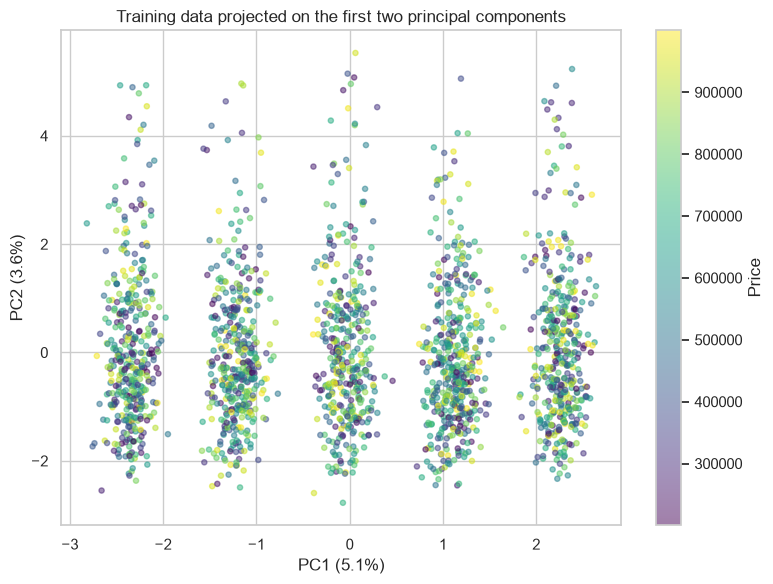


Top loadings - PC1
acc_count            0.606
acc_leather_seats    0.369
acc_gps              0.361
acc_music_system     0.358
acc_alloy_wheels     0.340
Name: PC1, dtype: float64

Top loadings - PC2
mileage_per_year    0.660
car_age            -0.543
mileage             0.404
fuel_type_Petrol    0.136
major_service_km    0.106
Name: PC2, dtype: float64

Top loadings - PC3
service_type_None                          0.488
major_service_km                          -0.484
transmission_type_Automatic (Tiptronic)   -0.433
transmission_type_Manual                   0.427
variant_XL                                 0.160
Name: PC3, dtype: float64


In [18]:
# First two components coloured by price - is there any visible structure?
Z2 = pca_full.transform(Xtr_std)[:, :2]

plt.figure(figsize=(8, 6))
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=y_train, cmap="viridis", alpha=0.5, s=14)
plt.colorbar(sc, label="Price")
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
plt.title("Training data projected on the first two principal components")
plt.tight_layout()
plt.show()

# Which original features drive the first components?
loadings = pd.DataFrame(pca_full.components_[:3].T, index=X_train_r.columns,
                        columns=["PC1", "PC2", "PC3"])
for pc in loadings.columns:
    print(f"\nTop loadings - {pc}")
    print(loadings[pc].sort_values(key=np.abs, ascending=False).head(5).round(3))

In [19]:
# Final PCA transform: keep enough components for 95% of the variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(Xtr_std)
X_train_p = pca.transform(Xtr_std)
X_test_p = pca.transform(Xte_std)

print(f"PCA output: {X_train_r.shape[1]} features -> {pca.n_components_} components "
      f"({pca.explained_variance_ratio_.sum():.1%} of variance retained)")

PCA output: 53 features -> 44 components (96.0% of variance retained)


### Modeling and Evaluation
####  Train-Test Split


In [20]:
feature_sets = {
    "A. All features":         (X_train_s.values, X_test_s.values),
    "B. Correlation-filtered": (X_train_r.values, X_test_r.values),
    "C. PCA (95% var.)":       (X_train_p,        X_test_p),
}

print(f"{'Feature set':<26}{'Train':>16}{'Test':>16}")
for name, (tr, te) in feature_sets.items():
    print(f"{name:<26}{str(tr.shape):>16}{str(te.shape):>16}")
print(f"\nTarget  train: {y_train.shape}  test: {y_test.shape}")

Feature set                          Train            Test
A. All features                 (2000, 55)       (500, 55)
B. Correlation-filtered         (2000, 53)       (500, 53)
C. PCA (95% var.)               (2000, 44)       (500, 44)

Target  train: (2000,)  test: (500,)


### Model Selection
We train a baseline that always predicts the training mean  which uses a DummyRegressor plus five models: Linear Regression, Ridge, k-Nearest Neighbours, Random Forest and Gradient Boosting. 
Models are compared with 5-fold cross-validation on the training set (RMSE), and the held-out test set is used only for the final report. The best model is chosen by cross-validated RMSE, not by test score.


In [21]:
models = {
    "Baseline (mean)":     DummyRegressor(strategy="mean"),
    "Linear Regression":   LinearRegression(),
    "Ridge":               Ridge(alpha=10.0),
    "KNN":                 KNeighborsRegressor(n_neighbors=15),
    "Random Forest":       RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                                 n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingRegressor(n_estimators=150, learning_rate=0.05,
                                                     max_depth=3, subsample=0.8,
                                                     random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []

for fs_name, (Xtr, Xte) in feature_sets.items():
    for m_name, model in models.items():
        cv_rmse = -cross_val_score(model, Xtr, y_train, cv=kf,
                                   scoring="neg_root_mean_squared_error").mean()
        model.fit(Xtr, y_train)
        pred = model.predict(Xte)
        rows.append({
            "feature_set": fs_name,
            "model": m_name,
            "cv_rmse": cv_rmse,
            "test_rmse": np.sqrt(mean_squared_error(y_test, pred)),
            "test_mae": mean_absolute_error(y_test, pred),
            "test_r2": r2_score(y_test, pred),
        })

results = pd.DataFrame(rows)
results.sort_values("cv_rmse").round(3).reset_index(drop=True)

,feature_set,model,cv_rmse,test_rmse,test_mae,test_r2
0,A. All features,Baseline (mean),230222.621,235629.371,205865.202,-0.002
1,C. PCA (95% var.),Baseline (mean),230222.621,235629.371,205865.202,-0.002
2,B. Correlation-filtered,Baseline (mean),230222.621,235629.371,205865.202,-0.002
3,C. PCA (95% var.),Random Forest,233274.437,237432.294,205931.299,-0.017
4,B. Correlation-filtered,Random Forest,233807.577,241693.606,210645.096,-0.054
5,A. All features,Random Forest,233813.228,241714.199,210673.383,-0.054
6,B. Correlation-filtered,Ridge,233848.881,237715.774,206282.651,-0.020
7,A. All features,Ridge,233873.592,237722.685,206359.440,-0.020
8,C. PCA (95% var.),Ridge,233988.810,237480.681,205999.149,-0.018
9,C. PCA (95% var.),Linear Regression,234030.792,237503.193,206006.540,-0.018


Test R2 (0 = same as predicting the mean, <0 = worse than the mean)


feature_set,A. All features,B. Correlation-filtered,C. PCA (95% var.)
model,,,
Baseline (mean),-0.0019,-0.0019,-0.0019
Gradient Boosting,-0.0430,-0.0452,-0.0200
KNN,-0.0938,-0.0972,-0.0789
Linear Regression,-0.0218,-0.0217,-0.0179
Random Forest,-0.0543,-0.0541,-0.0173
Ridge,-0.0198,-0.0197,-0.0177


Test RMSE


feature_set,A. All features,B. Correlation-filtered,C. PCA (95% var.)
model,,,
Baseline (mean),235629.0,235629.0,235629.0
Gradient Boosting,240422.0,240674.0,237756.0
KNN,246203.0,246582.0,244524.0
Linear Regression,237955.0,237950.0,237503.0
Random Forest,241714.0,241694.0,237432.0
Ridge,237723.0,237716.0,237481.0


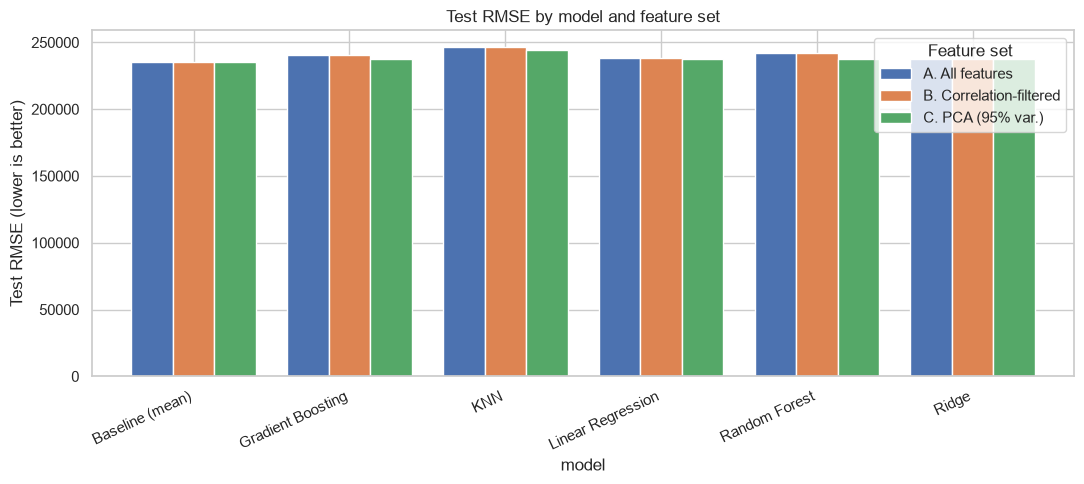

In [22]:
# Side-by-side view: test R2 and test RMSE per model and feature set
pivot_r2 = results.pivot(index="model", columns="feature_set", values="test_r2").round(4)
pivot_rmse = results.pivot(index="model", columns="feature_set", values="test_rmse").round(0)

print("Test R2 (0 = same as predicting the mean, <0 = worse than the mean)")
display(pivot_r2)
print("Test RMSE")
display(pivot_rmse)

fig, ax = plt.subplots(figsize=(11, 5))
pivot_rmse.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Test RMSE (lower is better)")
ax.set_title("Test RMSE by model and feature set")
plt.xticks(rotation=25, ha="right")
ax.legend(title="Feature set")
plt.tight_layout()
plt.show()

###  Why price_per_mile Is Excluded 
price_per_mile = price / mileage contains the answer we are trying to predict. To show the effect, we add it as an input to a Random Forest and compare it with the same model without it (feature set A). The near-perfect score below is not real performance: at prediction time for a new listing, the price is unknown, so this feature could not be computed.

In [24]:
ppm_train = df_fe.loc[X_train.index, "price_per_mile"].values.reshape(-1, 1)
ppm_test = df_fe.loc[X_test.index, "price_per_mile"].values.reshape(-1, 1)

rf_leak = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                n_jobs=-1, random_state=RANDOM_STATE)
rf_leak.fit(np.hstack([X_train_s.values, ppm_train]), y_train)
pred_leak = rf_leak.predict(np.hstack([X_test_s.values, ppm_test]))

rf_clean_r2 = results.query("model == 'Random Forest' and feature_set == 'A. All features'")["test_r2"].iloc[0]
print(f"Random Forest WITHOUT price_per_mile: test R2 = {rf_clean_r2:.4f}")
print(f"Random Forest WITH    price_per_mile: test R2 = {r2_score(y_test, pred_leak):.4f}  <- leakage, not real")

Random Forest WITHOUT price_per_mile: test R2 = -0.0543
Random Forest WITH    price_per_mile: test R2 = 0.9900  <- leakage, not real


In [25]:
summary = pd.DataFrame({
    "stage": ["Raw columns (16)", "After cleaning + feature engineering + one-hot (A)",
              "After correlation filter (B)", "After PCA, 95% variance (C)"],
    "n_features": [df.shape[1], X.shape[1], X_train_r.shape[1], pca.n_components_],
})
summary["change_vs_A"] = summary["n_features"] - X.shape[1]
summary.loc[0, "change_vs_A"] = np.nan
display(summary)

best_rows = (results[results["model"] != "Baseline (mean)"]
             .sort_values("cv_rmse").head(3)[["feature_set", "model", "cv_rmse", "test_rmse", "test_r2"]]
             .round(3))
print("Top 3 models by CV RMSE (baseline test RMSE = "
      f"{baseline_test_rmse:,.0f}):")
display(best_rows)

,stage,n_features,change_vs_A
0,Raw columns (16),16,NaN
1,After cleaning + feature engineering + one-hot...,55,0.0
2,After correlation filter (B),53,-2.0
3,"After PCA, 95% variance (C)",44,-11.0


Top 3 models by CV RMSE (baseline test RMSE = 235,629):


,feature_set,model,cv_rmse,test_rmse,test_r2
16,C. PCA (95% var.),Random Forest,233274.437,237432.294,-0.017
10,B. Correlation-filtered,Random Forest,233807.577,241693.606,-0.054
4,A. All features,Random Forest,233813.228,241714.199,-0.054


**Data preparation and feature engineering**
- No rows had to be dropped: `Variant` (10.5%) and `Accessories` (19.3%) were filled with explicit "Unknown" / "None" values, there were no duplicates, and the unique `Registration Number` was removed as an identifier.
- The 15 usable columns became **55 model-ready features**: `car_age`, `mileage_per_year`, parsed service-record fields, per-accessory flags, an accessory count, binary insurance / certificate flags, ordinal owner and tyre scores, and one-hot encodings of make, model, variant, fuel, transmission, colour and service type.
- `price_per_mile` was created as requested, but it is derived from the target and had to be excluded from the inputs.  Random Forest scores R² = 0.99, which shows some danger since the R² > 0

**Dimensionality reduction**
- The correlation filter removed only **2 features**: `make_year` (a perfect mirror of `car_age`, r = 1.00) and `service_type_Major` (r = 0.94 with `major_service_km`). Everything else was already close to independent.
- PCA needed **44 components** (from 53) to keep 95% of the variance, and 35 components for 80%. This is a modest reduction. PCA compresses *correlated* features, and this dataset is mostly made of independent one-hot and binary columns, so the variance is spread almost evenly across many components (the scree plot has no elbow).

**Model performance**
- **No model beat the baseline that simply predicts the average price.** In our run the baseline had a test RMSE of about 235.6k (R² = 0), while every model had an R² between roughly −0.10 and −0.02. The model ranked "best" by cross-validation (Random Forest on the PCA features) was still slightly worse than the baseline on the test set.
- The strongest single correlation between any feature and price was about 0.06, and the PCA projection showed no visible structure by price. Together with the EDA (all 100 model combinations exist, e.g. Kia Accord; price is flat across year, mileage, fuel and owner type), this strongly suggests the dataset is **synthetic and that price is essentially random noise with respect to the other columns.**
- Feature engineering and dimensionality reduction cannot create a signal that is not in the data. The small differences between feature sets A, B and C (for example PCA being slightly less bad for Random Forest and KNN) are within noise and should **not** be read as evidence that PCA improves the model. What can be said is that filtering and PCA reduced the feature space (55 → 53 → 44) **without losing anything measurable**, and that the linear models were practically identical across all three feature sets.

Conclusion: the pipeline is sound (no leakage, fit-on-train-only transformations, honest baseline), but with this dataset there is nothing to predict, so the useful result is the diagnosis rather than a good model.

### 7.2. Future Work
**Data**
- Repeat the analysis on real listing data (for example, scraped or public used-car listings), where depreciation with age and mileage, brand reputation and condition genuinely drive price.
- Add market features that are missing here: region/state, listing date, seller type, engine size, power, and a regional demand indicator.

**Additional feature engineering**
- Interaction and non-linear terms (age × mileage, brand × age, age²) and a log transform of the price target.
- Target or frequency encoding for high-cardinality columns such as model, instead of one-hot encoding.
- Compare "kilometres since the last major service" with the service record once the data is realistic.

**Further dimensionality reduction and modelling**
- Supervised feature selection (mutual information, L1/Lasso, permutation importance, recursive feature elimination) rather than only unsupervised filtering and PCA.
- Alternatives to PCA: truncated SVD for sparse one-hot data, Multiple Correspondence Analysis for categorical features, autoencoders, and t-SNE/UMAP for visualisation only.
- Put scaling, PCA and the model into a single scikit-learn `Pipeline` with nested cross-validation, tune hyper-parameters, and try tuned gradient-boosting libraries (XGBoost, LightGBM, CatBoost).
- Use repeated cross-validation and a paired statistical test before claiming that one feature set or model is better than another.